In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import analysis_tools as at

TILT_ROOT = Path("~/UNSW-PhD/seacofs_eddy_tilt_analysis").expanduser()
if str(TILT_ROOT) not in sys.path:
    sys.path.insert(0, str(TILT_ROOT))
import seacofs_tilt_tools as tilt

PROJECT_ROOT = Path("~/UNSW-MRes/MRes/seacofs_eddy_dataset_modular").expanduser()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
from seacofs_eddy_dataset.config import load_config

CONFIG_PATH = PROJECT_ROOT / "config" / "local.yaml"
config = load_config(CONFIG_PATH)

# Grid
from seacofs_eddy_dataset.core.grid import read_reference_grid
from seacofs_eddy_dataset.stages.detection import reference_grid_path
grid = read_reference_grid(reference_grid_path(config))


In [2]:
# df_eddies= pd.read_parquet(
#     config.output_root / "processed" / "eddy_dataset_processed.parquet"
# )
paths = tilt.Paths()
df_eddies, df_tilt = tilt.load_tilt_tables(paths, add_regions=True, grid=grid)
df_eddies.head()

,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,Rc,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir,Region
0,1,1462,CE,152.716333,-38.866383,171,26,474.560686,127.605656,-0.000032,...,29.449052,7.225911,1.973172,20.004291,26,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1
1,1,1463,CE,152.836206,-38.814279,173,28,482.821993,136.635735,-0.000041,...,29.449052,7.225911,1.859668,18.906549,26,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1
2,1,1464,CE,152.905198,-38.816261,175,28,488.606048,138.480541,-0.000035,...,32.090160,7.712683,1.745185,20.859920,26,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1
3,1,1465,CE,152.719389,-38.902070,171,25,475.960098,123.953440,-0.000020,...,34.827275,8.275696,1.433213,18.674495,26,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,19.823350,87.507772,D1
4,1,1466,CE,152.753007,-38.935135,172,25,479.803789,121.483614,-0.000026,...,37.564389,8.838709,1.140614,21.564028,26,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,15.055658,105.302388,D1


In [3]:
df_vert = pd.read_parquet(
    config.output_root / "vertical_profiles_confirmed" / "profiles.parquet"
)
df_vert

,Eddy,Day,fnumber,Depth,z,xc,yc,ic,jc,w,q11,q12,q22,Omega0,Omega,Rc,psi0,R
0,1,1462,1461,0.000000,0,474.560686,127.605656,171,26,-0.000032,1.758660,-0.532719,0.737370,NaN,-0.000013,29.449052,7.225911,20.004291
1,1,1462,1461,5.879627,1,476.056668,129.678745,171,26,-0.000030,1.628746,-0.329796,0.680748,-0.000013,-0.000013,35.798824,8.596591,19.126716
2,1,1462,1461,10.725783,2,476.887911,132.134805,172,27,-0.000030,1.593752,-0.319464,0.691486,-0.000013,-0.000014,33.615289,8.107898,21.330116
3,1,1462,1461,16.383097,3,476.324558,136.117738,171,28,-0.000033,1.776776,-0.280829,0.607204,-0.000014,-0.000016,31.928536,8.213464,20.137241
4,1,1462,1461,22.925581,4,478.387952,139.735396,172,28,-0.000034,1.787666,-0.425015,0.660435,-0.000014,-0.000017,30.093898,7.889563,21.334571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2824604,2982,10650,10641,515.416489,19,508.963912,299.374668,180,61,-0.000017,1.033282,-0.035786,0.969029,-0.000008,-0.000006,75.695297,16.693750,45.049156
2824605,2982,10650,10641,660.806374,20,508.678327,299.023082,180,61,-0.000014,1.045371,-0.055566,0.959552,-0.000007,-0.000005,78.656868,15.933899,46.467550
2824606,2982,10650,10641,858.918478,21,508.485388,298.326056,180,61,-0.000012,1.055097,-0.031142,0.948699,-0.000006,-0.000004,101.415168,18.656178,62.280573
2824607,2982,10650,10641,1128.898331,22,506.706507,297.269787,179,60,-0.000008,0.980631,0.030299,1.020688,-0.000004,-0.000003,115.807964,18.668141,82.943966


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


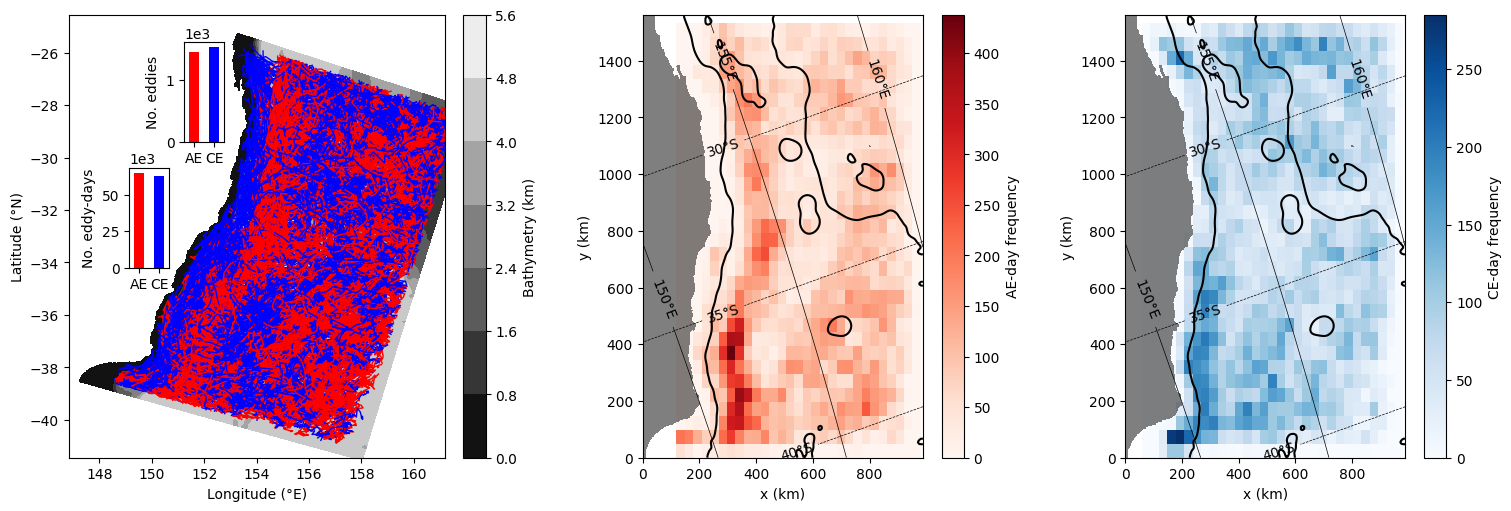

In [4]:
fig, axs = at.distribution_plot(df_eddies.copy(), grid)

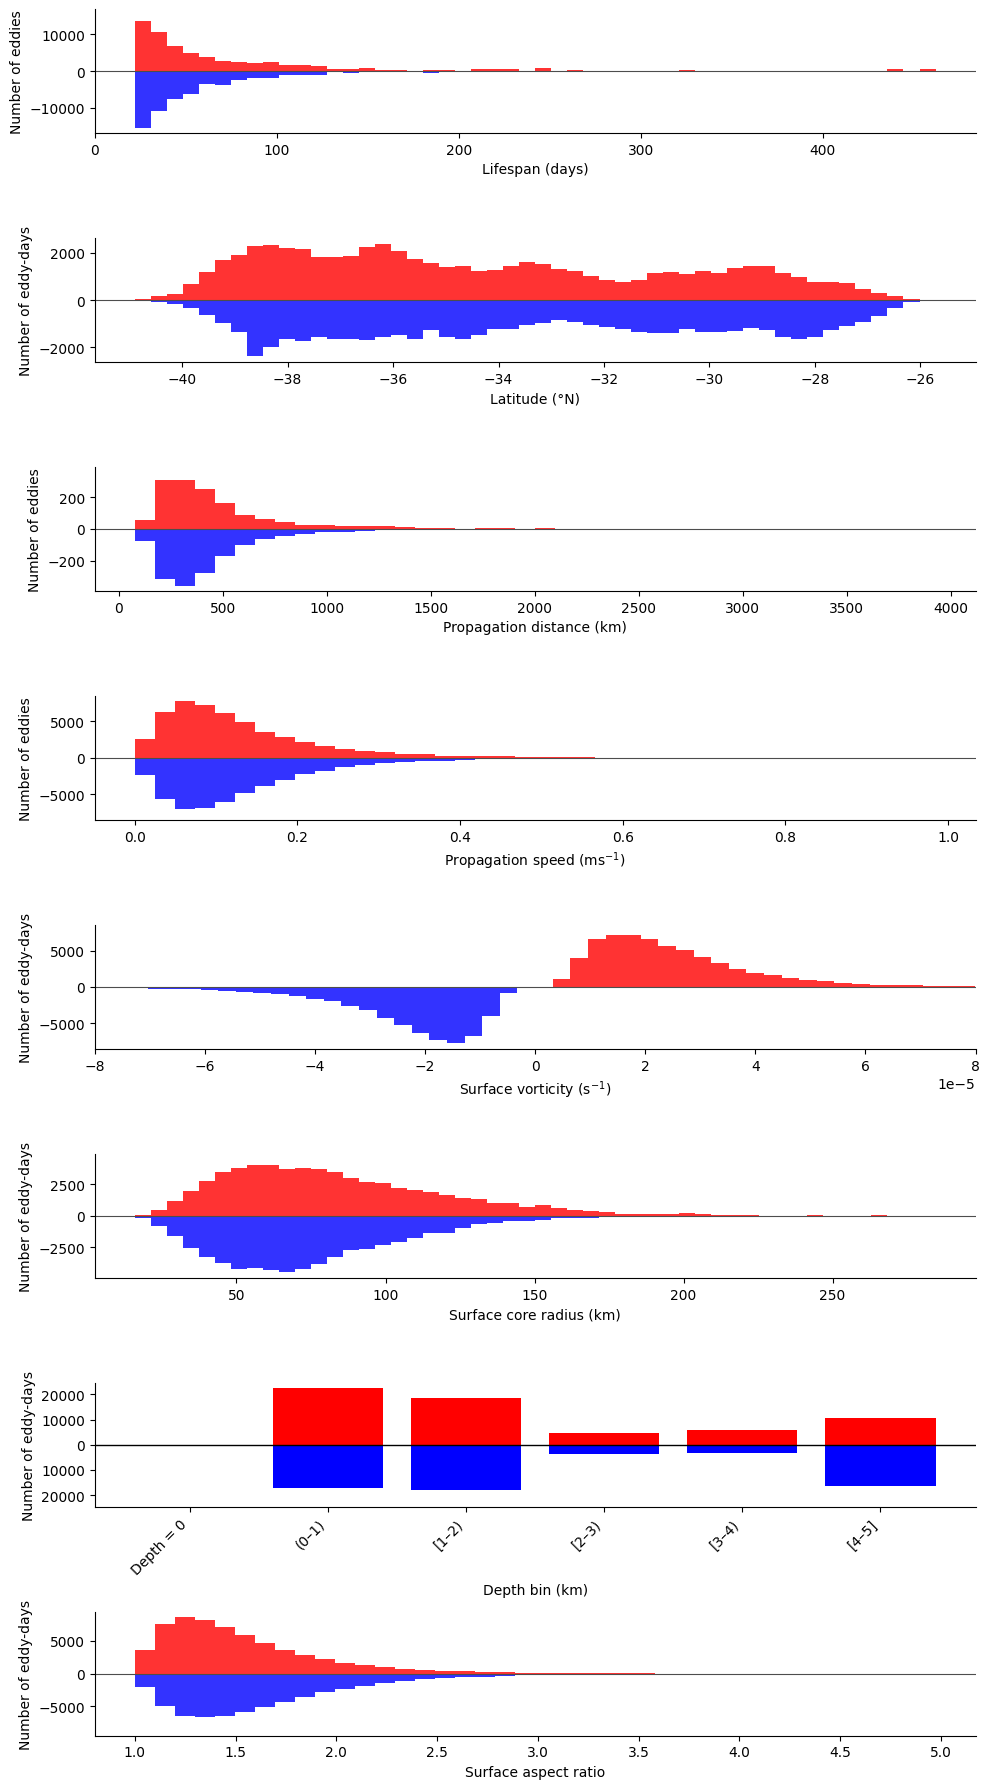

In [5]:
max_depth = (
    df_vert.groupby(["Eddy", "Day"], as_index=False)["Depth"]
    .max()
    .rename(columns={"Depth": "max_profile_depth"})
)
max_depth["max_profile_depth"] /= 1e3
df_eddies = df_eddies.merge(max_depth, on=["Eddy", "Day"], how="inner")
fig, axs = at.summary_plot(df_eddies.copy())

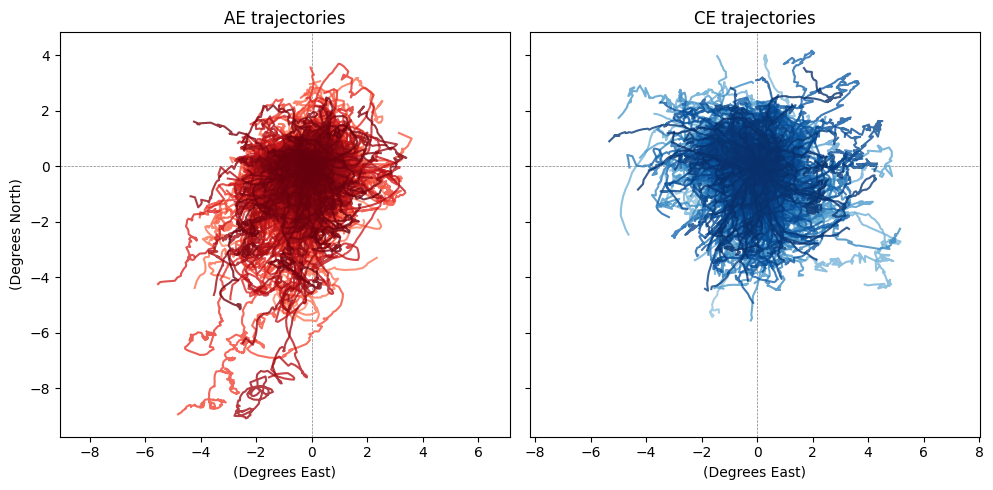

In [6]:
fig, axs = at.eddy_trajectories(df_eddies.copy())

In [7]:
dt = df_eddies.groupby('Eddy')['Day'].diff()
df_eddies['prop_x'] = df_eddies.groupby('Eddy')['xc'].diff() / dt
df_eddies['prop_y'] = df_eddies.groupby('Eddy')['yc'].diff() / dt
df_eddies['prop_dis'] = np.hypot(
    df_eddies['prop_x'],
    df_eddies['prop_y']
)
# Bearing: 0° = North, 90° = East
df_eddies['prop_dir'] = (
    np.degrees(
        np.arctan2(
            df_eddies['prop_x'],
            df_eddies['prop_y']
        )
    ) + 20
) % 360

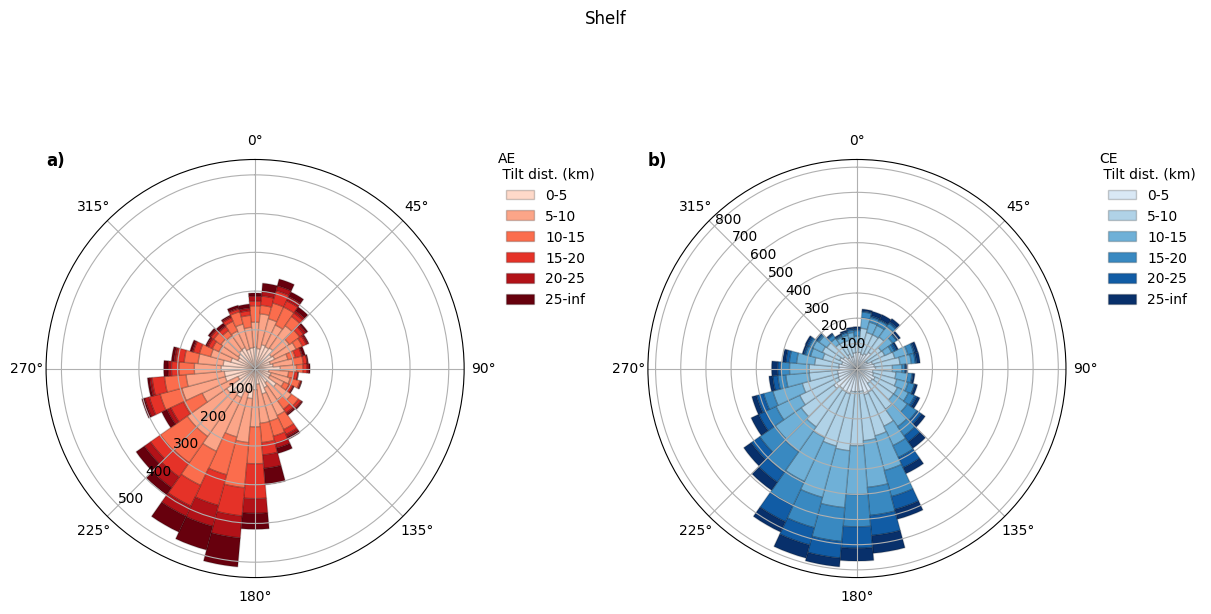

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 7), subplot_kw={"projection": "polar"}, constrained_layout=True)
# mag_bins = [0, 10, 20, 30, np.inf]
mag_bins = [0, 5, 10, 15, 20, 25, np.inf]
for ax, cyc, colors in zip(axs, ["AE", "CE"], [plt.cm.Reds(np.linspace(0.15, 1, len(mag_bins) - 1)), plt.cm.Blues(np.linspace(0.15, 1, len(mag_bins) - 1))]):
    subset = df_eddies.loc[df_eddies.Cyc == cyc].dropna(subset=["prop_dir", "prop_dis"])
    subset = subset[subset.Region.isin(['S1', 'S2'])]
    tilt.plot_windrose(ax, subset, title='', colors=colors, mag='prop_dis', theta='prop_dir', mag_bins=mag_bins)#, rlim=2300)# 
    ax.legend(title=f"{cyc}\n Tilt dist. (km)", loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=False)

    ax.text(-0.0, 1.02, 'a)' if cyc=='AE' else 'b)', transform=ax.transAxes,
                fontsize=12, fontweight='bold', va='top', ha='left')
plt.suptitle('Shelf')
plt.show()

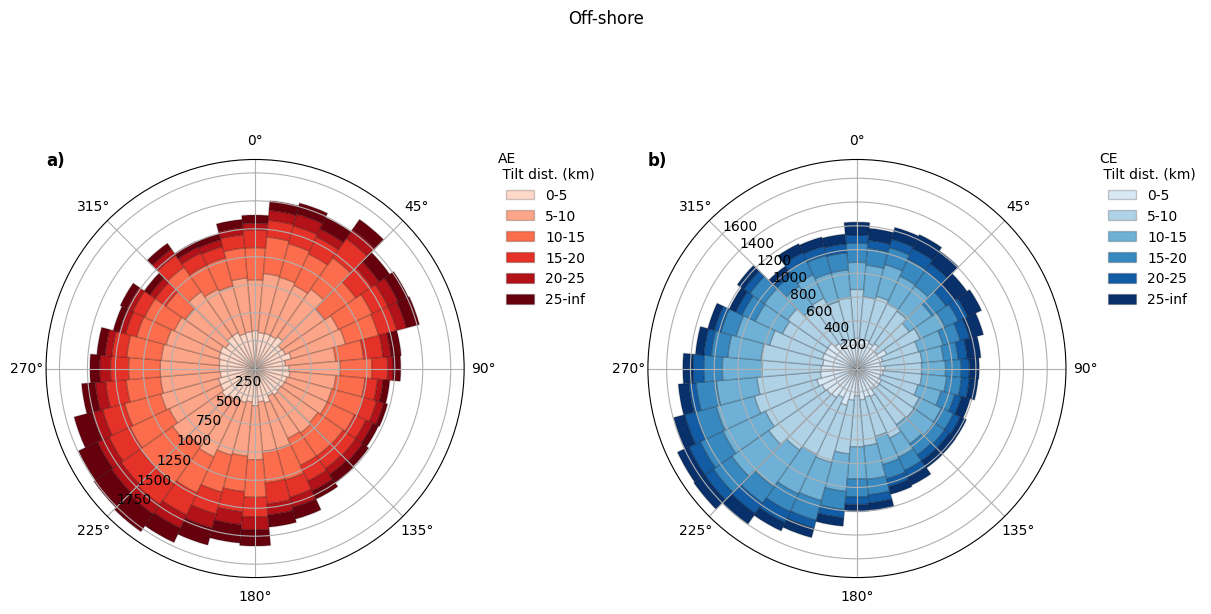

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 7), subplot_kw={"projection": "polar"}, constrained_layout=True)
mag_bins = [0, 5, 10, 15, 20, 25, np.inf]
for ax, cyc, colors in zip(axs, ["AE", "CE"], [plt.cm.Reds(np.linspace(0.15, 1, len(mag_bins) - 1)), plt.cm.Blues(np.linspace(0.15, 1, len(mag_bins) - 1))]):
    subset = df_eddies.loc[df_eddies.Cyc == cyc].dropna(subset=["prop_dir", "prop_dis"])
    subset = subset[subset.Region.isin(['U1','U2','D1','D2'])]
    tilt.plot_windrose(ax, subset, title='', colors=colors, mag='prop_dis', theta='prop_dir', mag_bins=mag_bins)#, rlim=2300)# 
    ax.legend(title=f"{cyc}\n Tilt dist. (km)", loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=False)

    ax.text(-0.0, 1.02, 'a)' if cyc=='AE' else 'b)', transform=ax.transAxes,
                fontsize=12, fontweight='bold', va='top', ha='left')
plt.suptitle('Off-shore')
plt.show()

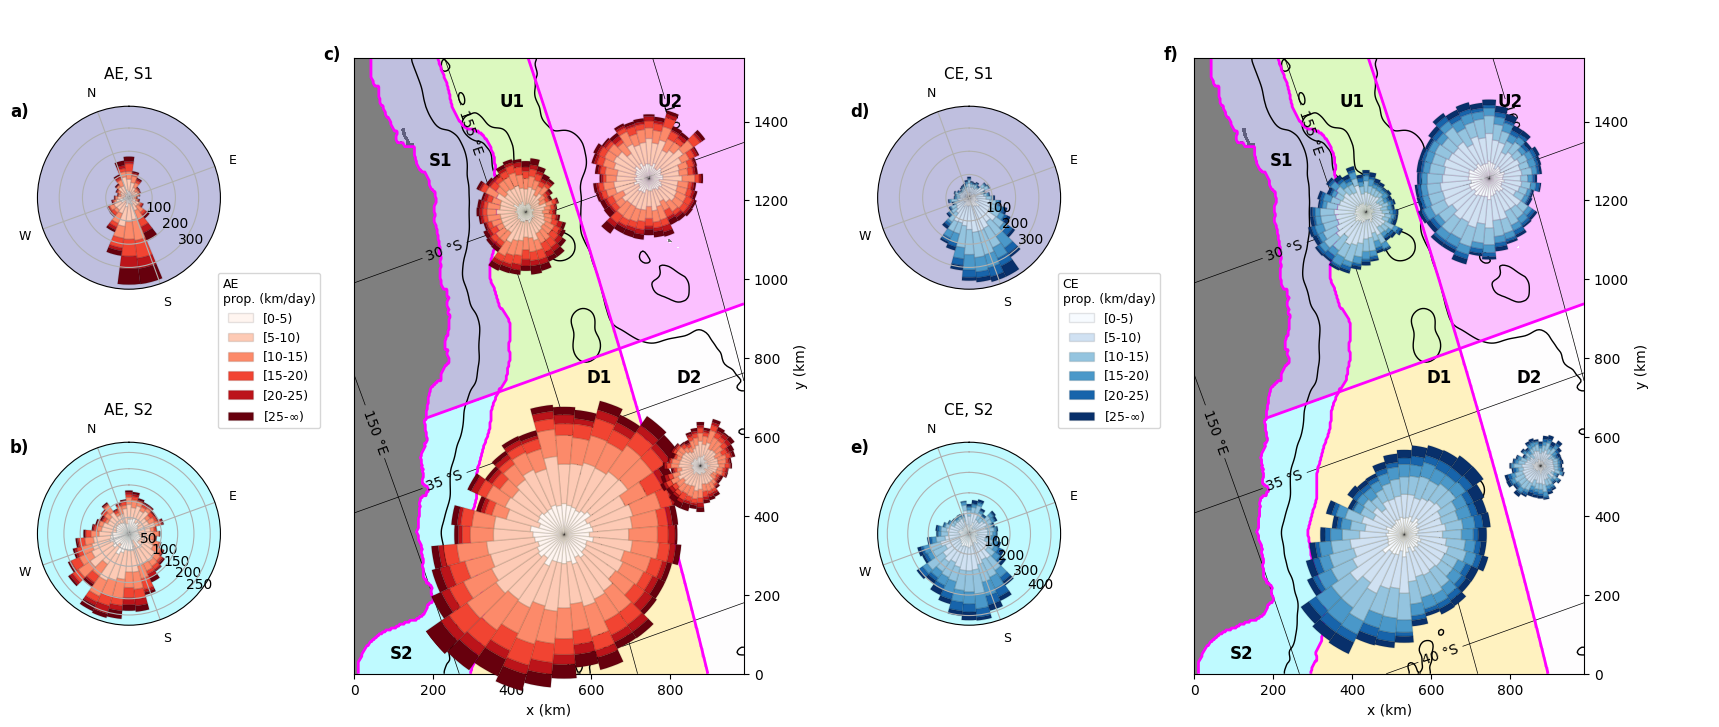

In [10]:
fig, rose = tilt.rose_plot(
    df_eddies.copy(),
    grid,
    mag="prop_dis",
    theta="prop_dir",
    frac=2.6,
    mag_bins=[0, 5, 10, 15, 20, 25, np.inf],
    legend_title="prop. (km/day)",
    cmaps = ['Reds', 'Blues']
)

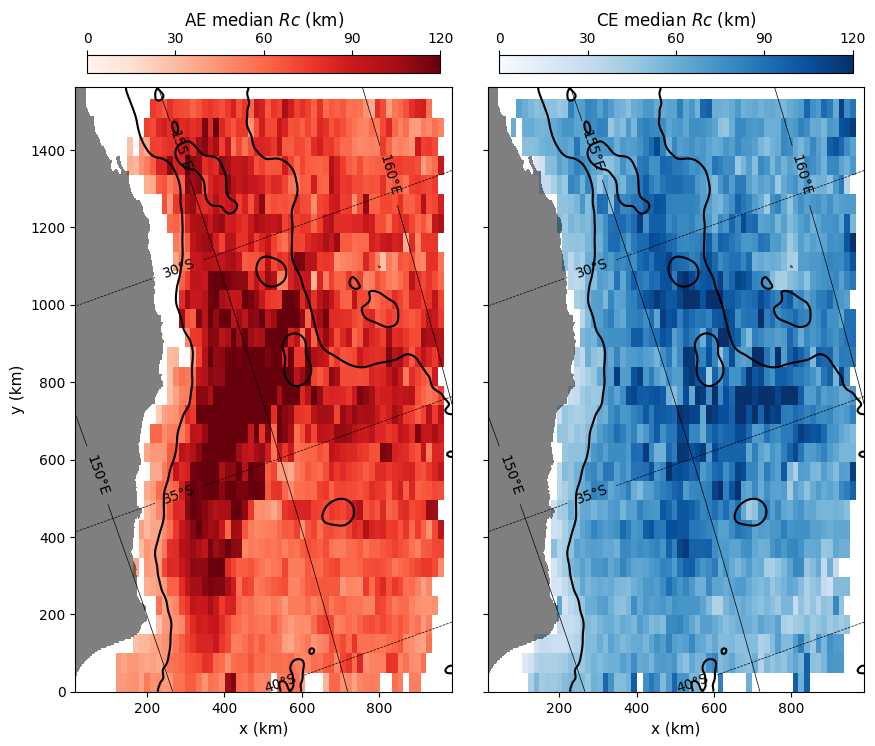

In [11]:
fig, axs = tilt.plot_binned_median_map(df_eddies.copy(), grid, 
                                       metric='Rc', vmin=0, vmax=120)

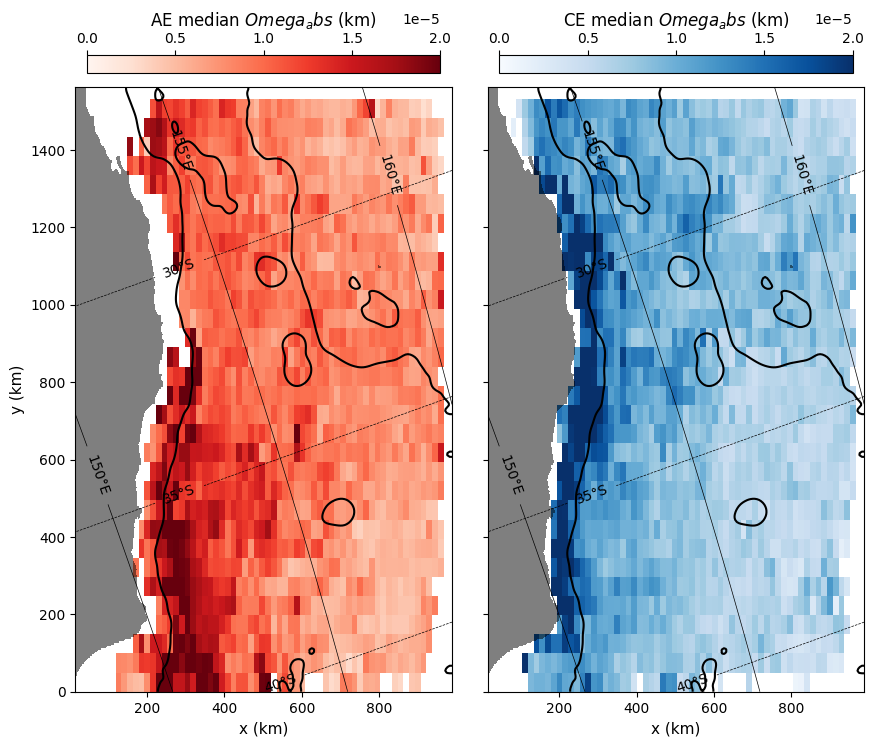

In [12]:
df = df_eddies.copy()
df['Omega_abs'] = df_eddies.Omega.abs()
fig, axs = tilt.plot_binned_median_map(df, grid, 
                                       metric='Omega_abs', vmin=0, vmax=2e-5)

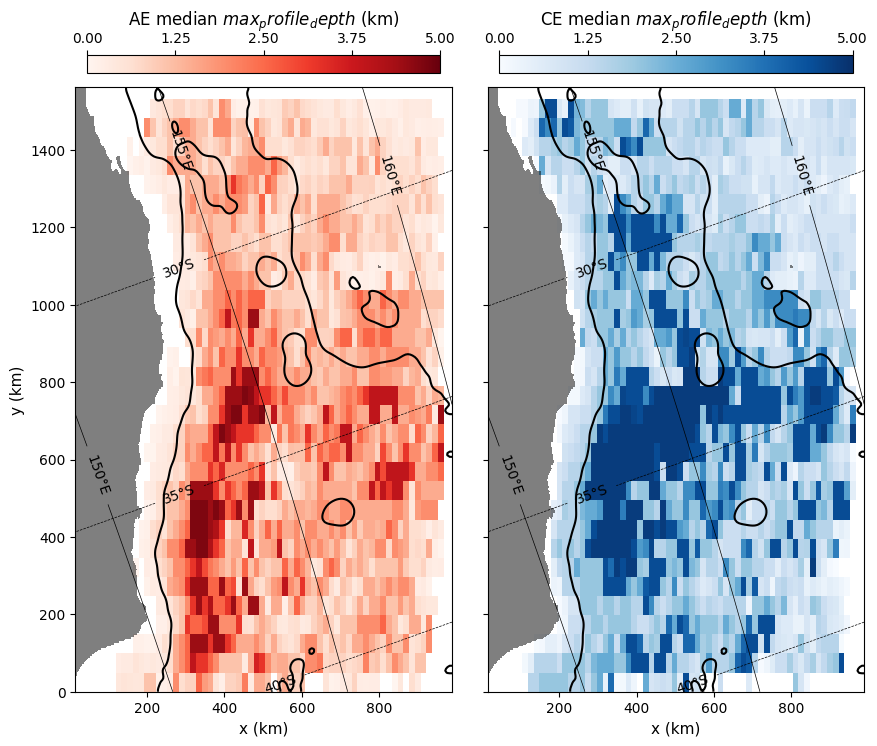

In [13]:
fig, axs = tilt.plot_binned_median_map(df_eddies.copy(), grid, 
                                       metric='max_profile_depth', vmin=0, vmax=5)

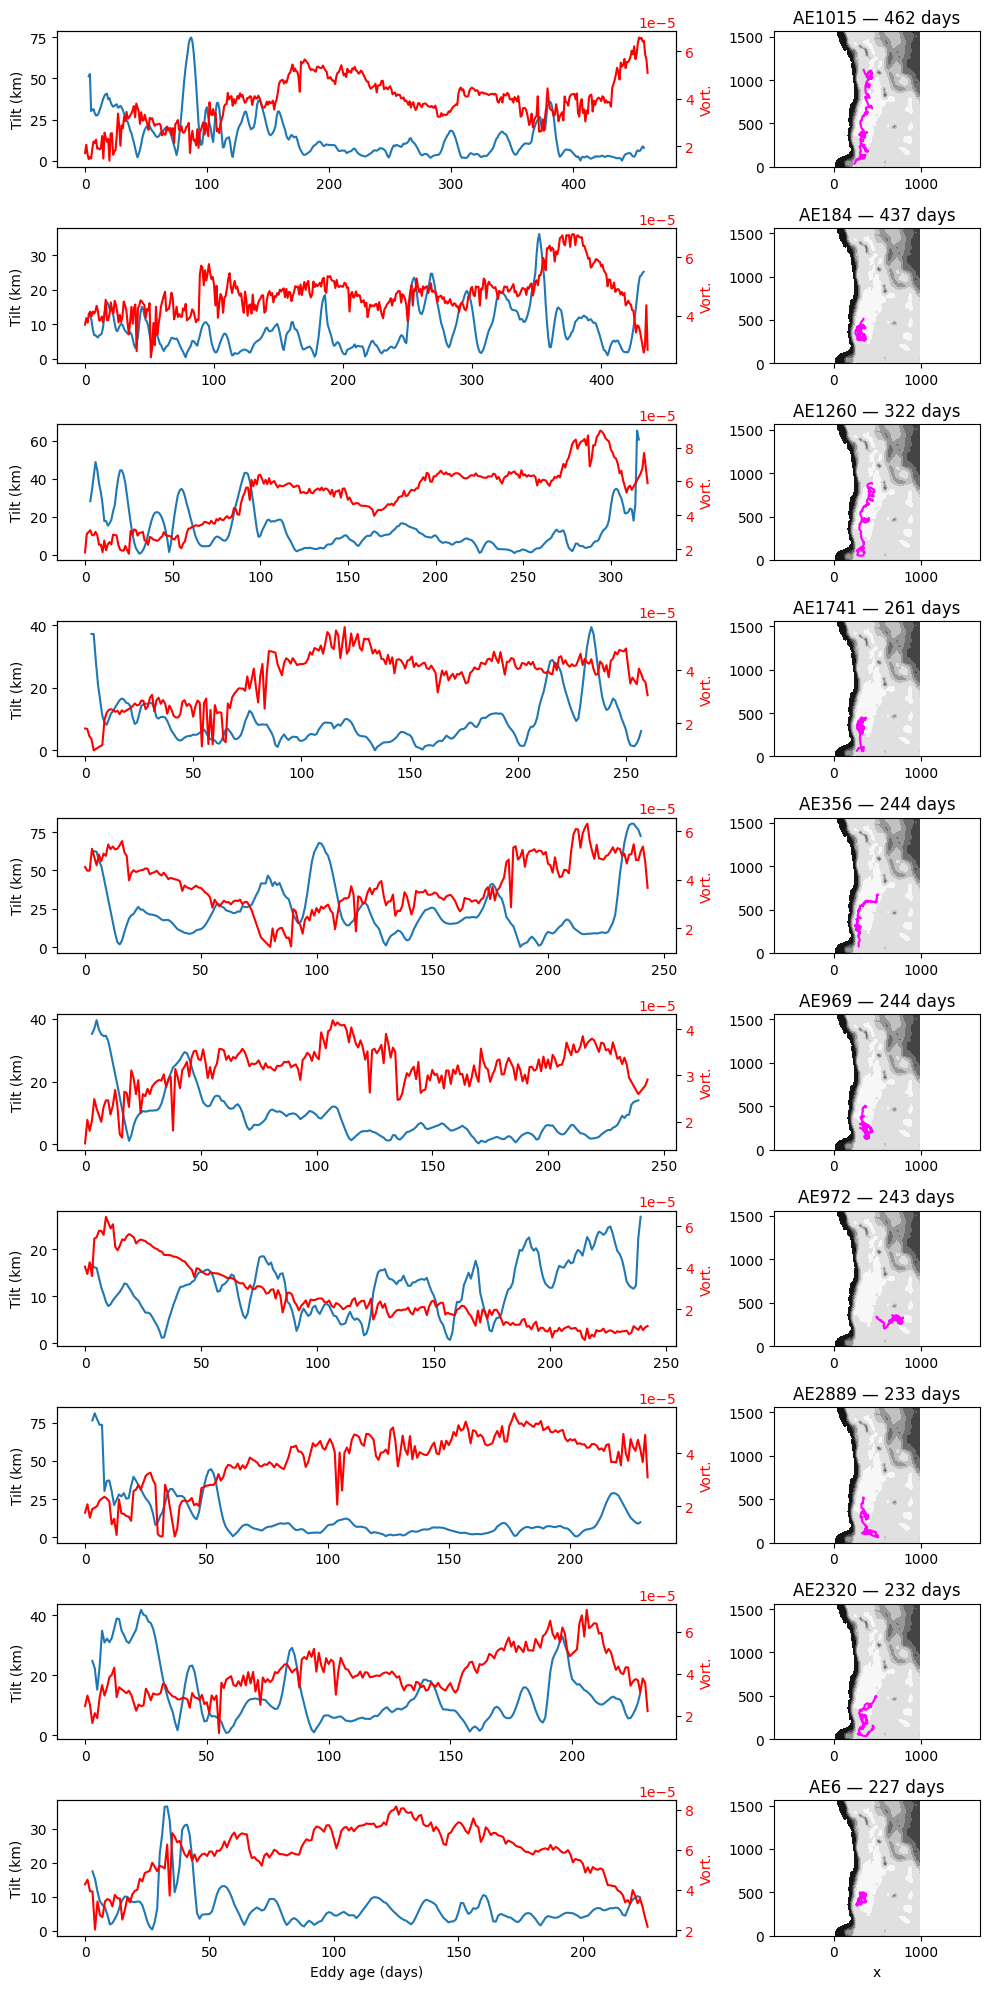

In [14]:
fig, axs = tilt.tilt_t(df_eddies.copy(), grid, add_field='w', field_label='Vort.')